## Data Processing and Modeling Pipeline

This section reorganizes the previous code into a structured pipeline. Each major step of the data workflow (loading, cleaning, feature engineering, EDA, scaling, and model training) is encapsulated within a function for better organization, reusability, and readability.
### Pipeline Stages:
1.  **Configuration and Setup**: Importing necessary libraries and defining global parameters.
2.  **Data Loading**: load the dataset.
3.  **Initial Data Inspection**: Functions to check for nulls, infinities, and display basic information.
4.  **Data Cleaning & Preprocessing**: Functions for column name cleanup, handling duplicates, and imputing missing values.
5.  **Feature Engineering**: Functions to create or transform features like `Timestamp` and related time-based metrics.
6.  **Exploratory Data Analysis (EDA) & Visualization**: Functions to generate the various plots and insights previously developed.
7.  **Feature Selection & Scaling**: Functions to prepare features and target, and apply scaling.
8.  **Model Training & Evaluation**: Functions to train the Random Forest Classifier and visualize feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer

### 1. Data Loading Stage

In [2]:
df = pd.read_csv("merged.csv")
print("Data loaded successfully.")
display(df.head())

Data loaded successfully.


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### 2. Initial Data Inspection Stage

In [3]:
def inspect_data(df):
    """Performs initial data inspection: info, nulls, and infinities."""
    print("\n--- DataFrame Info ---")
    df.info()

    print("\n--- Null Value Counts ---")
    null_counts = df.isnull().sum()
    null_columns = null_counts[null_counts > 0]
    if not null_columns.empty:
        print("Columns with null values:")
        display(null_columns.sort_values(ascending=False))
    else:
        print("No null values found in any column.")

    print("\n--- Infinite Value Counts ---")
    numeric_df = df.select_dtypes(include=np.number)
    inf_counts = numeric_df.isin([np.inf, -np.inf]).sum()
    inf_columns = inf_counts[inf_counts > 0]
    if not inf_columns.empty:
        print("Columns with infinite values:")
        display(inf_columns.sort_values(ascending=False))
    else:
        print("No infinite values found in any numeric column.")
    
    return df 


### 3. Data Cleaning & Preprocessing Stage

In [4]:
def clean_column_names(df):
    """Cleans column names by stripping spaces and standardizing format."""
    print("Cleaning column names...")
    original_columns = df.columns.tolist()
    df.columns = df.columns.astype(str).str.strip().str.replace(' ', '_').str.replace('[^A-Za-z0-9_]+', '', regex=True)
    print("Column names cleaned.")
    # Display changes if any
    if original_columns != df.columns.tolist():
        print("Some column names were changed. Example original vs new:")
        for orig, new in zip(original_columns[:5], df.columns.tolist()[:5]):
            if orig != new:
                print(f"  '{orig}' -> '{new}'")
    return df

def drop_irrelevant_columns(df):
    """Drops columns identified as irrelevant or highly correlated for the final model."""
    current_columns = df.columns.tolist()
    columns_to_keep_final = []

    # Explicitly keep 'Time' and 'Label'
    columns_to_keep_final.extend(['Time', 'Label'])

    # Keywords for 'flows', 'bytes', 'ports' categories
    # 'Length', 'Size', 'Segment' are included in bytes_keywords as they represent byte-related measurements.
    flow_keywords = ['Flow', 'IAT', 'Active', 'Idle']
    bytes_keywords = ['Bytes', 'Length', 'Size', 'Segment', 'Init_Win_bytes']
    port_keywords = ['Port']

    # Iterate through columns and add to final list if they match criteria
    for col in current_columns:
        if col in columns_to_keep_final:
            continue

        if any(pk in col for pk in port_keywords):
            columns_to_keep_final.append(col)
            continue

        if any(fk in col for fk in flow_keywords):
            columns_to_keep_final.append(col)
            continue

        if any(bk in col for bk in bytes_keywords):
            columns_to_keep_final.append(col)
            continue

    # Drop columns that are NOT in `columns_to_keep_final`
    columns_to_drop = [col for col in current_columns if col not in columns_to_keep_final]

    # Explicit list of columns to drop as per previous notebook cells
    columns_to_drop_now = [
        'Fwd_Packet_Length_Max',
        'Fwd_Packet_Length_Min',
        'Fwd_Packet_Length_Mean',
        'Fwd_Packet_Length_Std',
        'Bwd_Packet_Length_Max',
        'Bwd_Packet_Length_Min',
        'Bwd_Packet_Length_Mean',
        'Bwd_Packet_Length_Std',
        'Flow_IAT_Mean',
        'Flow_IAT_Std',
        'Flow_IAT_Max',
        'Flow_IAT_Min',
        'Fwd_IAT_Total',
        'Fwd_IAT_Mean',
        'Fwd_IAT_Std',
        'Fwd_IAT_Max',
        'Fwd_IAT_Min',
        'Bwd_IAT_Mean',
        'Bwd_IAT_Std',
        'Bwd_IAT_Max',
        'Bwd_IAT_Min',
        'Min_Packet_Length',
        'Max_Packet_Length',
        'Packet_Length_Mean',
        'Packet_Length_Std',
        'Packet_Length_Variance',
        "Idle_Min",
        "Idle_Max",
        "Idle_Mean",
        "Idle_Std",
        "Active_Min",
        "Active_Mean",
        "Active_Max",
        "Active_Std",
        "Total_Length_of_Fwd_Packets",
        "Total_Length_of_Bwd_Packets",
        "Bwd_IAT_Total",
        "Fwd_Header_Length",
        "Bwd_Header_Length",
        "Avg_Fwd_Segment_Size",
        "Avg_Bwd_Segment_Size",
        "Fwd_Header_Length_1", # Handle potential duplicate column names after cleaning
        "Bwd_Avg_BytesBulk",
        "Fwd_Avg_BytesBulk",
        # Add 'time' and 'cumulative_time' if they somehow resurface
        'time', 
        'cumulative_time', 
        'Timestamp', 
        'seconds_from_midnight_full'
    ]

    # Combine all columns to drop
    all_columns_to_drop = list(set(columns_to_drop + columns_to_drop_now))
    all_columns_to_drop = [col for col in all_columns_to_drop if col in df.columns]

    print(f"Dropping {len(all_columns_to_drop)} columns...")
    df.drop(columns=all_columns_to_drop, inplace=True, errors='ignore')

    print(f"Dropped {len(all_columns_to_drop)} additional columns. New DataFrame shape: {df.shape}")
    print("Remaining columns:")
    print(df.columns.tolist())
    display(df.head())
    return df

def handle_duplicates(df):
    """Removes duplicate rows from the DataFrame."""
    initial_rows = len(df)
    num_duplicates = df.duplicated().sum()
    if num_duplicates > 0:
        print(f"Found {num_duplicates} duplicate rows. Removing...")
        df.drop_duplicates(inplace=True)
        print(f"Removed duplicates. DataFrame now has {len(df)} rows.")
    else:
        print("No duplicate rows found.")
    return df

def impute_missing_values(df, n_neighbors=5):
    """Imputes missing numerical values using KNNImputer and handles infinite values."""
    print("Imputing missing values using KNNImputer...")
    
    # Identify numerical columns for imputation
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

    # Separate numerical and non-numerical columns
    df_numerical = df[numerical_cols].copy()
    df_non_numerical = df.drop(columns=numerical_cols)

    # Replace infinite values with NaN before imputation
    df_numerical.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Initialize and perform KNNImputer
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df_imputed_numerical = imputer.fit_transform(df_numerical)
    df_imputed_numerical = pd.DataFrame(df_imputed_numerical, columns=numerical_cols, index=df.index)

    # Recombine with non-numerical columns
    df_cleaned = pd.concat([df_imputed_numerical, df_non_numerical], axis=1)

    print("Missing values after KNN imputation (should be 0):")
    print(df_cleaned.isnull().sum().sum())
    print("DataFrame head after imputation:")
    display(df_cleaned.head())
    
    return df_cleaned


### 4. Feature Engineering Stage

In [5]:
def create_synthetic_timestamps(df, start_time_str='2017-07-03 08:00:00', end_time_str='2017-07-07 17:00:00'):
    """Creates a synthetic Timestamp column for visualizing attack occurrences over time."""
    print("Creating synthetic 'Timestamp' column...")
    start_time = pd.Timestamp(start_time_str)
    end_time = pd.Timestamp(end_time_str)
    n_rows = len(df)
    synthetic_timestamps = pd.date_range(start=start_time, end=end_time, periods=n_rows)
    df['Timestamp'] = synthetic_timestamps
    
    # Convert 'Time' to string to avoid errors if it was previously a datetime.time object
    if 'Time' in df.columns: # Check if 'Time' column exists before trying to modify it.
        df['Time'] = df['Timestamp'].dt.time.astype(str) # Convert to string to avoid future dtype issues in non-numeric context
    else:
        df['Time'] = df['Timestamp'].dt.time.astype(str)

    df['seconds_from_midnight_full'] = df['Timestamp'].dt.hour * 3600 + \
                                         df['Timestamp'].dt.minute * 60 + \
                                         df['Timestamp'].dt.second

    print(f"New 'Timestamp', 'Time', and 'seconds_from_midnight_full' columns created.")
    print(f"Start: {df['Timestamp'].min()}, End: {df['Timestamp'].max()}")
    display(df[['Timestamp', 'Time', 'seconds_from_midnight_full', 'Flow_Duration', 'Label']].head())
    return df


### 5. Exploratory Data Analysis (EDA) & Visualization Stage

In [6]:
def plot_flow_duration_over_time(df, n_records=10000):
    """Plots flow duration over the synthetic timestamp for a subset of records."""
    print(f"Plotting Flow Duration over Time for the first {n_records} records...")
    df_plot = df.head(n_records).copy()

    plt.figure(figsize=(15, 6))
    plt.plot(df_plot['Timestamp'], df_plot['Flow_Duration'], color='royalblue', linewidth=1)
    plt.yscale('log')
    plt.title(f'Flow Duration Over Time (First {n_records} Records)', fontsize=14)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel('Flow Duration (Microseconds - Log Scale)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_flow_duration_ts(df, n_records=10000, time_col='Timestamp', duration_col='Flow Duration'):
    """Plotting the time series for Flow Duration for a given number of records.
    
    Parameters:
        - df: The DataFrame containing the data.
        - n_records: The number of records to display from the beginning (default 10,000).
        - time_col: The name of the time column.
        - duration_col: The name of the flow duration column.
    """
    
    if time_col not in df.columns or duration_col not in df.columns:
        print(f"Error: One of the columns '{time_col}' or '{duration_col}' is missing.")
        return

    df_plot = df.head(n_records).copy()

    plt.figure(figsize=(15, 6))
    plt.plot(df_plot[time_col], df_plot[duration_col], color='darkblue', linewidth=1)
    plt.yscale('log')
    plt.title(f'Time Series: {duration_col} (First {n_records} Records)', fontsize=14)
    plt.xlabel('Time (Synthetic Timeline)', fontsize=12)
    plt.ylabel(f'{duration_col} (Microseconds - Log Scale)', fontsize=12)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_flow_duration_timeseries(df, n_records=10000, time_col='Timestamp', duration_col='Flow Duration'):
    """
    Visualizes the Flow Duration as a time series for the specified number of records.
    
    Parameters:
    - df: DataFrame containing the network traffic data.
    - n_records: The number of initial records to plot (default is 10,000).
    - time_col: Name of the timestamp column.
    - duration_col: Name of the flow duration column.
    """
    
    df_subset = df.head(n_records).copy()

    plt.figure(figsize=(15, 6))
    plt.plot(df_subset[time_col], df_subset[duration_col], color='mediumblue', linewidth=1)
    plt.yscale('log')
    plt.title(f'Flow Duration Over Time (First {n_records} Records)', fontsize=14)
    plt.xlabel('Timestamp (July 2017)', fontsize=12)
    plt.ylabel(f'{duration_col} (Microseconds - Log Scale)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_time_progression(df, timestamp_col='Timestamp'):
    """
    Calculates seconds from midnight for the daily cycle and plots time progression 
    against the data index for the full dataset.
    
    Parameters:
    - df: DataFrame containing the dataset.
    - timestamp_col: Name of the column with datetime objects (default is 'Timestamp').
    """
    
    print("Calculating seconds from midnight...")
    
    df['seconds_from_midnight_full'] = df[timestamp_col].dt.hour * 3600 + \
                                       df[timestamp_col].dt.minute * 60 + \
                                       df[timestamp_col].dt.second

    plt.figure(figsize=(15, 6))
    plt.plot(df.index, df['seconds_from_midnight_full'], color='teal', linewidth=0.1, alpha=0.5)
    plt.title('Time Progression vs Data Index (Full Dataset)', fontsize=14)
    plt.xlabel('Data Index (Total Records)', fontsize=12)
    plt.ylabel('Seconds from Midnight', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df

def plot_attack_distribution_over_time(df):
    """Visualizes the distribution of attack types over the synthetic time series."""
    print("Plotting Distribution of Attack Types Over Time...")
    sns.set_theme(style="whitegrid")

    # 1. Ensure Timestamp is actually a datetime object (Fixes the Dtype 'O' error)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    
    attack_df = df[df['Label'] != 'BENIGN'].copy()
    
    # Ensure 'Label' is string type and clean
    attack_df['Label'] = attack_df['Label'].astype(str).str.replace(' ', '_').str.replace('[^A-Za-z0-9_]+', '', regex=True)

    if not attack_df.empty:
        min_dt = attack_df['Timestamp'].min()
        max_dt = attack_df['Timestamp'].max()
        
        # Create bins
        datetime_bins = pd.date_range(start=min_dt, end=max_dt + pd.Timedelta(hours=3), freq='3h')
        # 2. Convert bins to numeric for Seaborn compatibility
        numerical_bins_mpl = mdates.date2num(datetime_bins)

        plt.figure(figsize=(15, 7))
        
        # 3. Use the numerical_bins_mpl here
        sns.histplot(
            data=attack_df,
            x='Timestamp',
            hue='Label',
            multiple='stack',
            bins=numerical_bins_mpl, 
            palette='Spectral',
            legend=True
        )

        plt.title('Distribution of Attack Types Over Time', fontsize=16)
        plt.xlabel('Timestamp (July 2017)', fontsize=12)
        plt.ylabel('Number of Attacks', fontsize=12)

        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No attack traffic found after filtering 'BENIGN' labels for plotting.")
 
def plot_feature_distributions(X, N=20):
    """Plots distributions of selected important numerical features."""
    print(f"Plotting distributions of top {N} features...")
    sns.set_theme(style="whitegrid")
    
    # If X is a DataFrame and has already calculated feature importances
    # For this function, let's assume X has been preprocessed and contains numeric data
    # We'll just pick some representative features for now.
    selected_features_for_hist = X.columns[:min(N, len(X.columns))] # Take first N or all if less than N

    plt.figure(figsize=(16, 4 * ((len(selected_features_for_hist) + 1) // 2))) # Dynamic sizing
    for i, feature in enumerate(selected_features_for_hist, 1):
        plt.subplot(len(selected_features_for_hist) // 2 + (len(selected_features_for_hist) % 2), 2, i)
        sns.histplot(X[feature], bins=50, kde=True)
        plt.title(f'Distribution of {feature}', fontsize=14)
        plt.xlabel(feature, fontsize=10)
        plt.ylabel('Frequency', fontsize=10)
        plt.yscale('log', nonpositive='clip')

    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(df, top_features_df=None, N=20):
    """Plots the correlation matrix of top N features, and with encoded labels if provided."""
    print(f"Plotting Correlation Matrix of Top {N} Important Features...")
    sns.set_theme(style="whitegrid")

    if top_features_df is None:
        # If no specific top features dataframe is given, just use a sample of numeric columns
        numeric_cols = df.select_dtypes(include=np.number).columns
        if len(numeric_cols) > N:
            sample_cols = np.random.choice(numeric_cols, N, replace=False)
            correlation_matrix = df[sample_cols].corr()
            title = f'Correlation Matrix of Sample {N} Numeric Features'
        else:
            correlation_matrix = df[numeric_cols].corr()
            title = f'Correlation Matrix of All Numeric Features ({len(numeric_cols)})'
    else:
        top_features = top_features_df['Feature'].head(N).tolist()
        # Ensure all top_features are present in df's columns
        available_top_features = [f for f in top_features if f in df.columns]
        correlation_matrix = df[available_top_features].corr()
        title = f'Correlation Matrix of Top {len(available_top_features)} Most Important Features'

    plt.figure(figsize=(15, 12))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_feature_distributions_by_attack_type(df):
    """Uses violin plots to show feature distributions grouped by attack type."""
    print("Plotting Feature Distributions by Attack Type using Violin plots...")
    sns.set_theme(style="whitegrid")

    selected_features_for_violin = [
        'Packet_Length_Variance', # Ensure these column names exist after cleaning
        'Packet_Length_Std',
        'Max_Packet_Length',
        'Destination_Port'
    ]
    
    # Filter to only include features that actually exist in the DataFrame
    existing_features = [f for f in selected_features_for_violin if f in df.columns]
    if not existing_features:
        print("None of the selected features for violin plots exist after preprocessing. Skipping plot.")
        return

    plot_df = df[existing_features + ['Label']].copy()
    
    # Handle cases where `Label` might not be clean or might have very few samples for some types
    plot_df['Label'] = plot_df['Label'].astype(str).str.replace(' ', '_').str.replace('[^A-Za-z0-9_]+', '', regex=True)

    plt.figure(figsize=(18, 5 * len(existing_features)))
    for i, feature in enumerate(existing_features, 1):
        plt.subplot(len(existing_features), 1, i)
        sns.violinplot(x='Label', y=feature, data=plot_df, inner='quartile', palette='viridis', hue='Label', legend=False)
        plt.title(f'Distribution of {feature} by Attack Type', fontsize=14)
        plt.xlabel('Attack Type', fontsize=12)
        plt.ylabel(feature, fontsize=12)
        plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


### 6. Feature Selection & Scaling Stage

In [7]:
def prepare_features_and_target(df, target_column='Label', cols_to_exclude=['Time']):
    """Prepares feature matrix (X) and target vector (y), handling non-numeric columns and encoding labels."""
    print("Preparing features (X) and target (y)...")
    
    # Drop non-numeric and target columns for feature selection
    # 'Time' is an object type, so we exclude it.
    # 'Label' is our target variable.
    exclude_cols = [target_column] + [col for col in cols_to_exclude if col in df.columns]
    features_df = df.drop(columns=exclude_cols, errors='ignore')

    # Select only numeric columns for features
    X = features_df.select_dtypes(include=['number'])

    # Handle potential NaN values by filling with the mean (or a more sophisticated method if needed)
    # Note: Infinities should ideally be handled by impute_missing_values step
    X = X.fillna(X.mean())
    
    # Target variable
    y = df[target_column].astype(str) # Ensure target is string for LabelEncoder

    # Encode target variable if it's categorical (Random Forest expects numeric labels)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    print(f"Original label categories: {list(le.classes_)}")
    print(f"Encoded label categories: {list(range(len(le.classes_)))}")
    print(f"Shape of X: {X.shape}, Shape of y: {y_encoded.shape}")
    display(X.head())
    return X, y_encoded, le

def scale_features(X, scaler_type='StandardScaler'):
    """Applies feature scaling to the input feature matrix X."""
    print(f"Applying {scaler_type} to features...")
    if scaler_type == 'StandardScaler':
        scaler = StandardScaler()
    elif scaler_type == 'MinMaxScaler':
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaler_type must be 'StandardScaler' or 'MinMaxScaler'")

    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    
    print(f"Features after {scaler_type} (first 5 rows):")
    display(X_scaled_df.head())
    print("Descriptive statistics for a sample feature after scaling:")
    display(X_scaled_df.describe().loc[['mean', 'std', 'min', 'max'], 'Destination_Port'].to_frame())
    return X_scaled_df, scaler


### 7. Model Training & Evaluation Stage

In [8]:
def train_random_forest_model(X, y_encoded, test_size=0.3, random_state=42, n_estimators=100):
    """Splits data, trains a RandomForestClassifier, and prints results."""
    print("Splitting data into training and testing sets...")
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=test_size, random_state=random_state)

    print(f"Training RandomForestClassifier with {n_estimators} estimators...")
    rf_classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, n_jobs=-1)
    rf_classifier.fit(X_train, y_train)

    print("Random Forest Classifier trained successfully.")
    return rf_classifier, X_train, X_test, y_train, y_test

def visualize_feature_importances(rf_classifier, X_columns, N=20):
    """Visualizes the top N most important features from a trained RandomForestClassifier."""
    print(f"Visualizing top {N} most important features...")
    feature_importances = rf_classifier.feature_importances_

    features_importance_df = pd.DataFrame({
        'Feature': X_columns,
        'Importance': feature_importances
    })

    features_importance_df = features_importance_df.sort_values(by='Importance', ascending=False)

    print(f"\nTop {N} Most Important Features:")
    display(features_importance_df.head(N))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=features_importance_df.head(N), palette='viridis')
    plt.title(f'Top {N} Most Important Features (Random Forest)', fontsize=16)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()
    return features_importance_df


### Executing the Pipeline

In [9]:
# --- Pipeline Execution --- 

# Initial Data Inspection
df_inspected = inspect_data(df.copy()) 


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18

Flow Bytes/s    1358
dtype: int64


--- Infinite Value Counts ---
Columns with infinite values:


 Flow Packets/s    2867
Flow Bytes/s       1509
dtype: int64

In [10]:
# 3. Data Cleaning & Preprocessing
df_cleaned_names = clean_column_names(df_inspected)
df_dropped = drop_irrelevant_columns(df_cleaned_names)
df_deduplicated = handle_duplicates(df_dropped)
df_imputed = impute_missing_values(df_deduplicated)

Cleaning column names...
Column names cleaned.
Some column names were changed. Example original vs new:
  ' Destination Port' -> 'Destination_Port'
  ' Flow Duration' -> 'Flow_Duration'
  ' Total Fwd Packets' -> 'Total_Fwd_Packets'
  ' Total Backward Packets' -> 'Total_Backward_Packets'
  'Total Length of Fwd Packets' -> 'Total_Length_of_Fwd_Packets'
Dropping 68 columns...
Dropped 68 additional columns. New DataFrame shape: (2830743, 11)
Remaining columns:
['Destination_Port', 'Flow_Duration', 'Flow_Bytess', 'Flow_Packetss', 'Average_Packet_Size', 'Fwd_Header_Length1', 'Subflow_Fwd_Bytes', 'Subflow_Bwd_Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Label']


,Destination_Port,Flow_Duration,Flow_Bytess,Flow_Packetss,Average_Packet_Size,Fwd_Header_Length1,Subflow_Fwd_Bytes,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,Label
0,80,38308,3.132505e+02,52.208416,9.000000,20,6,6,255,946,BENIGN
1,389,479,1.039666e+06,33402.922760,31.125000,368,172,326,29200,260,BENIGN
2,88,1095,5.753425e+06,14611.872150,393.750000,336,3150,3150,29200,2081,BENIGN
3,389,15206,6.650007e+05,1907.141918,348.689655,560,3452,6660,29200,0,BENIGN
4,88,1092,5.771062e+06,13736.263740,420.133333,304,3150,3152,29200,2081,BENIGN


Found 449104 duplicate rows. Removing...
Removed duplicates. DataFrame now has 2381639 rows.
Imputing missing values using KNNImputer...
Missing values after KNN imputation (should be 0):
0
DataFrame head after imputation:


,Destination_Port,Flow_Duration,Flow_Bytess,Flow_Packetss,Average_Packet_Size,Fwd_Header_Length1,Subflow_Fwd_Bytes,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,Label
0,80.0,38308.0,3.132505e+02,52.208416,9.000000,20.0,6.0,6.0,255.0,946.0,BENIGN
1,389.0,479.0,1.039666e+06,33402.922760,31.125000,368.0,172.0,326.0,29200.0,260.0,BENIGN
2,88.0,1095.0,5.753425e+06,14611.872150,393.750000,336.0,3150.0,3150.0,29200.0,2081.0,BENIGN
3,389.0,15206.0,6.650007e+05,1907.141918,348.689655,560.0,3452.0,6660.0,29200.0,0.0,BENIGN
4,88.0,1092.0,5.771062e+06,13736.263740,420.133333,304.0,3150.0,3152.0,29200.0,2081.0,BENIGN


Creating synthetic 'Timestamp' column...
New 'Timestamp', 'Time', and 'seconds_from_midnight_full' columns created.
Start: 2017-07-03 08:00:00, End: 2017-07-07 17:00:00


,Timestamp,Time,seconds_from_midnight_full,Flow_Duration,Label
0,2017-07-03 08:00:00.000000000,08:00:00,28800,38308.0,BENIGN
1,2017-07-03 08:00:00.158714296,08:00:00.158714,28800,479.0,BENIGN
2,2017-07-03 08:00:00.317428593,08:00:00.317428,28800,1095.0,BENIGN
3,2017-07-03 08:00:00.476142889,08:00:00.476142,28800,15206.0,BENIGN
4,2017-07-03 08:00:00.634857186,08:00:00.634857,28800,1092.0,BENIGN


Plotting Flow Duration over Time for the first 10000 records...


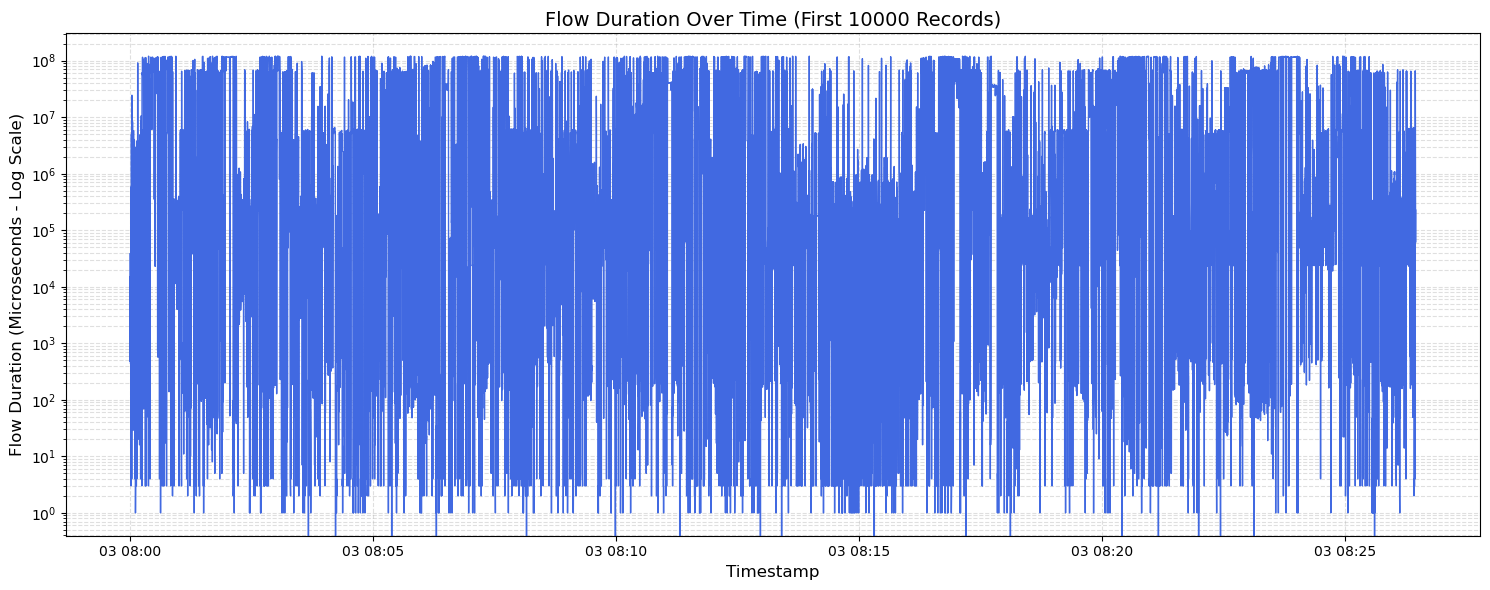

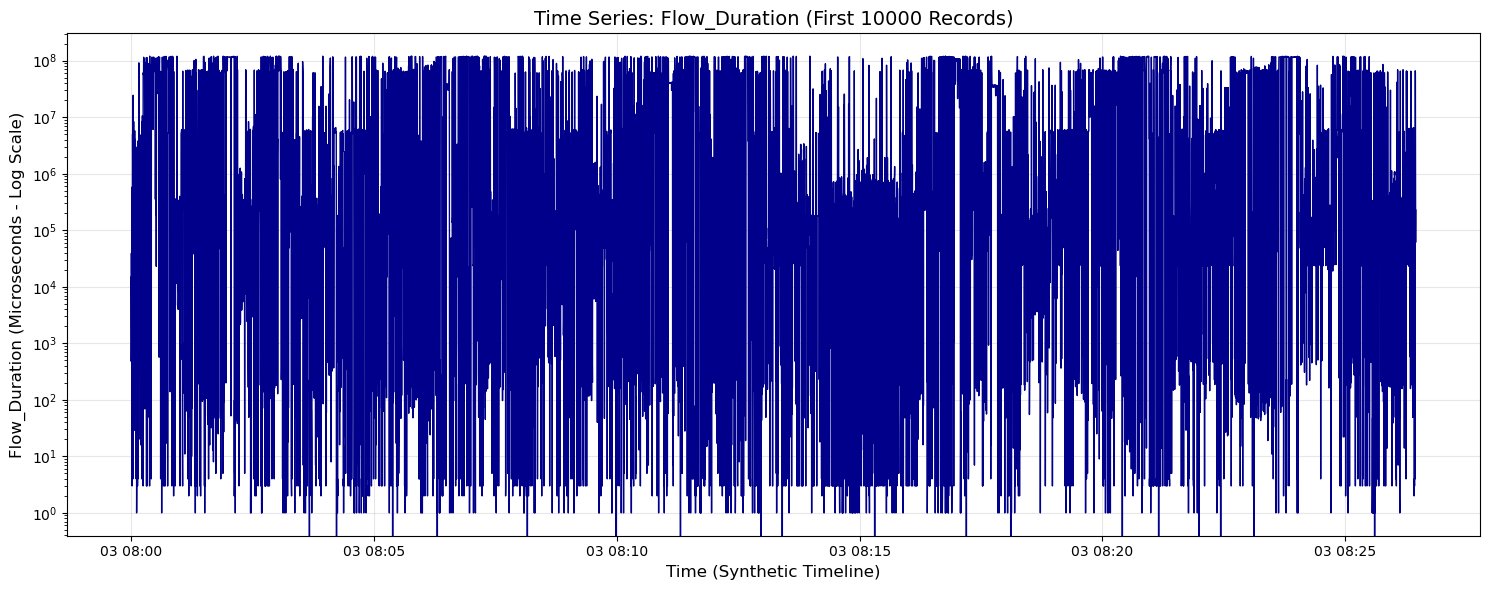

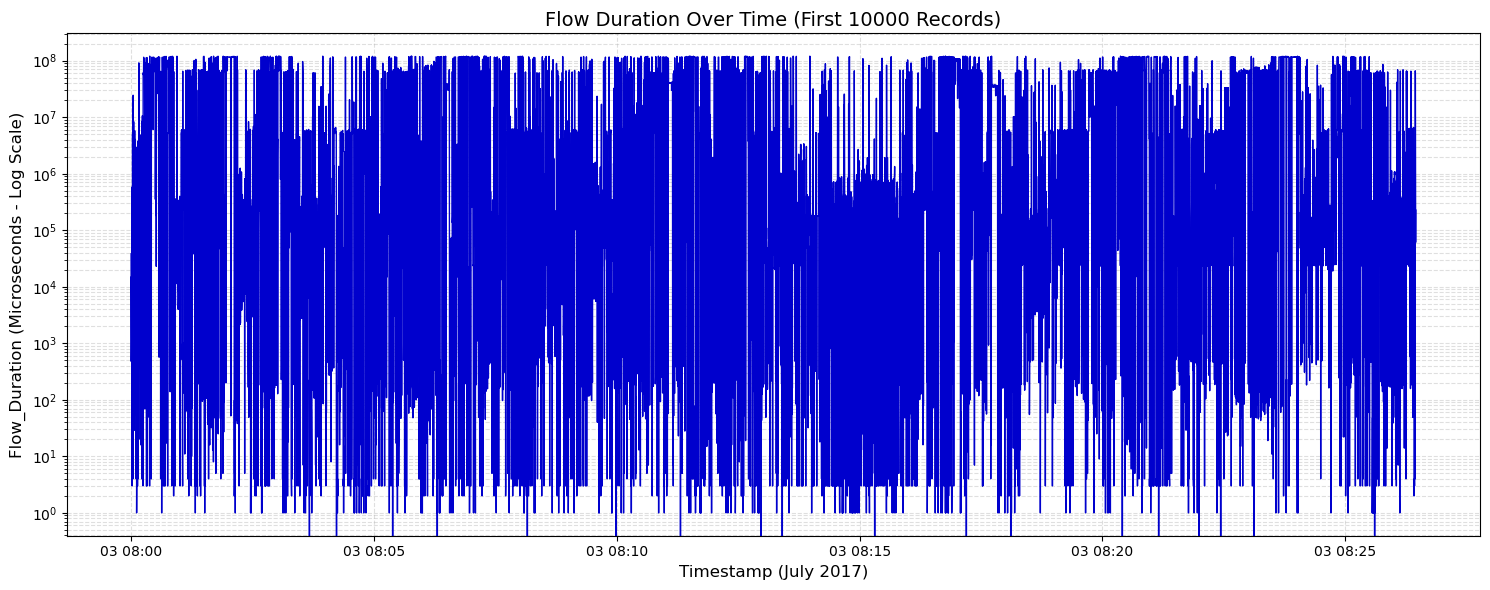

Calculating seconds from midnight...


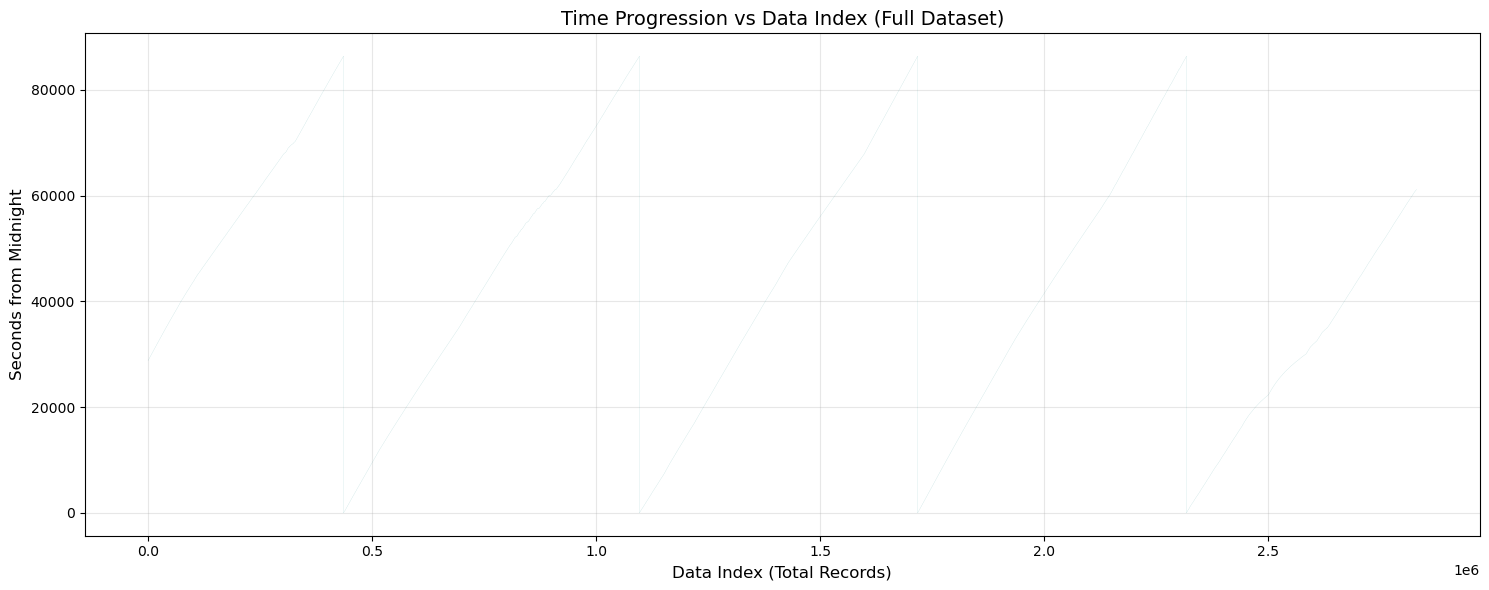

Plotting Distribution of Attack Types Over Time...


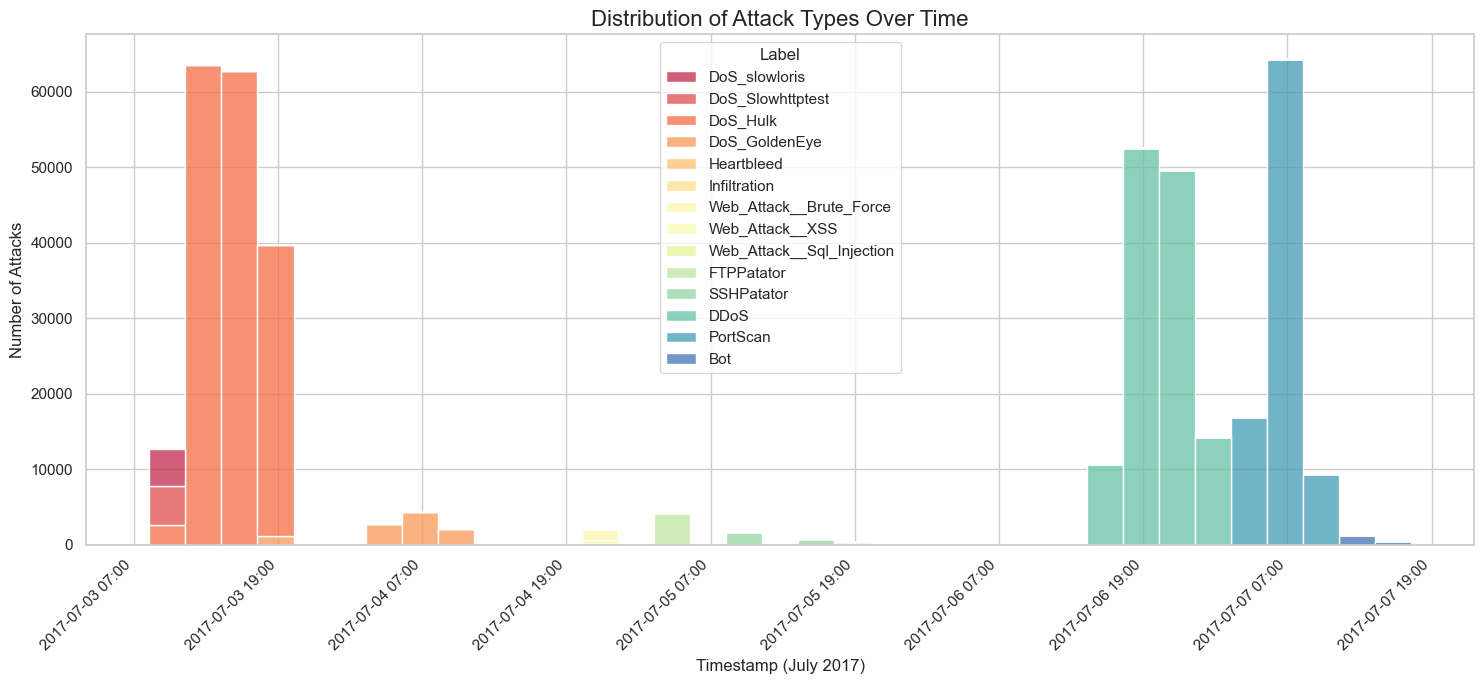

In [13]:
df_engineered = create_synthetic_timestamps(df_imputed)
df_engineered['Timestamp'] = pd.to_datetime(df_engineered['Timestamp'])


plot_flow_duration_over_time(df_engineered)
plot_flow_duration_ts(df_engineered, n_records=10000, duration_col='Flow_Duration')
plot_flow_duration_timeseries(df_engineered, n_records=10000, duration_col='Flow_Duration')
df_engineered = plot_time_progression(df_engineered)
plot_attack_distribution_over_time(df_engineered)

Based on figure 1:
- Extreme Oscillation: The traffic exhibits rapid, high-amplitude spikes across eight orders of magnitude, ranging from $10^0$ to $10^8$ microseconds.
- Constant Density: There is no significant downtime; the network is saturated with a continuous mix of instantaneous and long-lived flows.
- Logarithmic Uniformity: Despite the scale, the distribution is relatively uniform across the 25-minute window, indicating a stable but highly heterogeneous traffic profile.
- Baseline Noise: A consistent "floor" of short-duration traffic (likely protocol overhead or heartbeats) persists throughout the entire sequence.

Based on figure 2:
 - Extreme Variance: Flow durations fluctuate rapidly across eight orders of magnitude, from 1 microsecond to over 100 seconds ($10^8$ $\mu s$).
 - Dense Activity: The "vertical spike" pattern indicates a constant mix of very short control packets and long-duration data transfers.
 - Sustained Traffic: No significant idle periods are visible, suggesting a continuous stream of diverse network protocols.Logarithmic 
 - Distribution: The log scale shows a heavy concentration of both extremely short and extremely long flows, typical of mixed network traffic.

Based on figure 3:
- Extreme Magnitude Variance: The data spikes rapidly between 1 microsecond ($10^0$) and over 100 seconds ($10^8$ $\mu s$).
- Bimodal Traffic Profile: The plot shows a clear concentration of both instantaneous control flows and very long-lived data sessions.
- Persistent Saturation: There is continuous network activity across the entire 25-minute window with no observable downtime.
- Logarithmic Stability: The log-scale visualization demonstrates that despite the volatility, the range of flow behaviors remains consistent over time.

Based on figure 4:
- Cyclical 24-Hour Patterns: The sawtooth waveform clearly illustrates four complete daily cycles, where "Seconds from Midnight" resets to zero at the start of each new day.
- Linear Data Collection: The steady upward slopes indicate that data records were captured at a relatively consistent rate throughout each day.
- Dataset Scale: The x-axis shows the dataset contains nearly 3 million total records ($2.5 \times 10^6$ to $3.0 \times 10^6$), spanning approximately four and a half days of network activity.
- Continuous Monitoring: The lack of horizontal plateaus suggests there were no significant interruptions in data logging over the multi-day period.

Figure 5: Attack Distribution Over Time key patterns:

DDoS and PortScan attacks appear to be most prominent, with significant spikes at different times.
Some attack types, like DoS Hulk, show a more continuous presence over a period, while others like DoS GoldenEye and FTP-Patator occur in more concentrated bursts.
The timeline indicates that different attack campaigns might be active during specific hours or days, which is crucial for understanding attack strategies and developing time-sensitive detection mechanisms.

Preparing features (X) and target (y)...
Original label categories: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Encoded label categories: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Shape of X: (2381639, 11), Shape of y: (2381639,)


,Destination_Port,Flow_Duration,Flow_Bytess,Flow_Packetss,Average_Packet_Size,Fwd_Header_Length1,Subflow_Fwd_Bytes,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,seconds_from_midnight_full
0,80.0,38308.0,3.132505e+02,52.208416,9.000000,20.0,6.0,6.0,255.0,946.0,28800
1,389.0,479.0,1.039666e+06,33402.922760,31.125000,368.0,172.0,326.0,29200.0,260.0,28800
2,88.0,1095.0,5.753425e+06,14611.872150,393.750000,336.0,3150.0,3150.0,29200.0,2081.0,28800
3,389.0,15206.0,6.650007e+05,1907.141918,348.689655,560.0,3452.0,6660.0,29200.0,0.0,28800
4,88.0,1092.0,5.771062e+06,13736.263740,420.133333,304.0,3150.0,3152.0,29200.0,2081.0,28800


Plotting distributions of top 20 features...


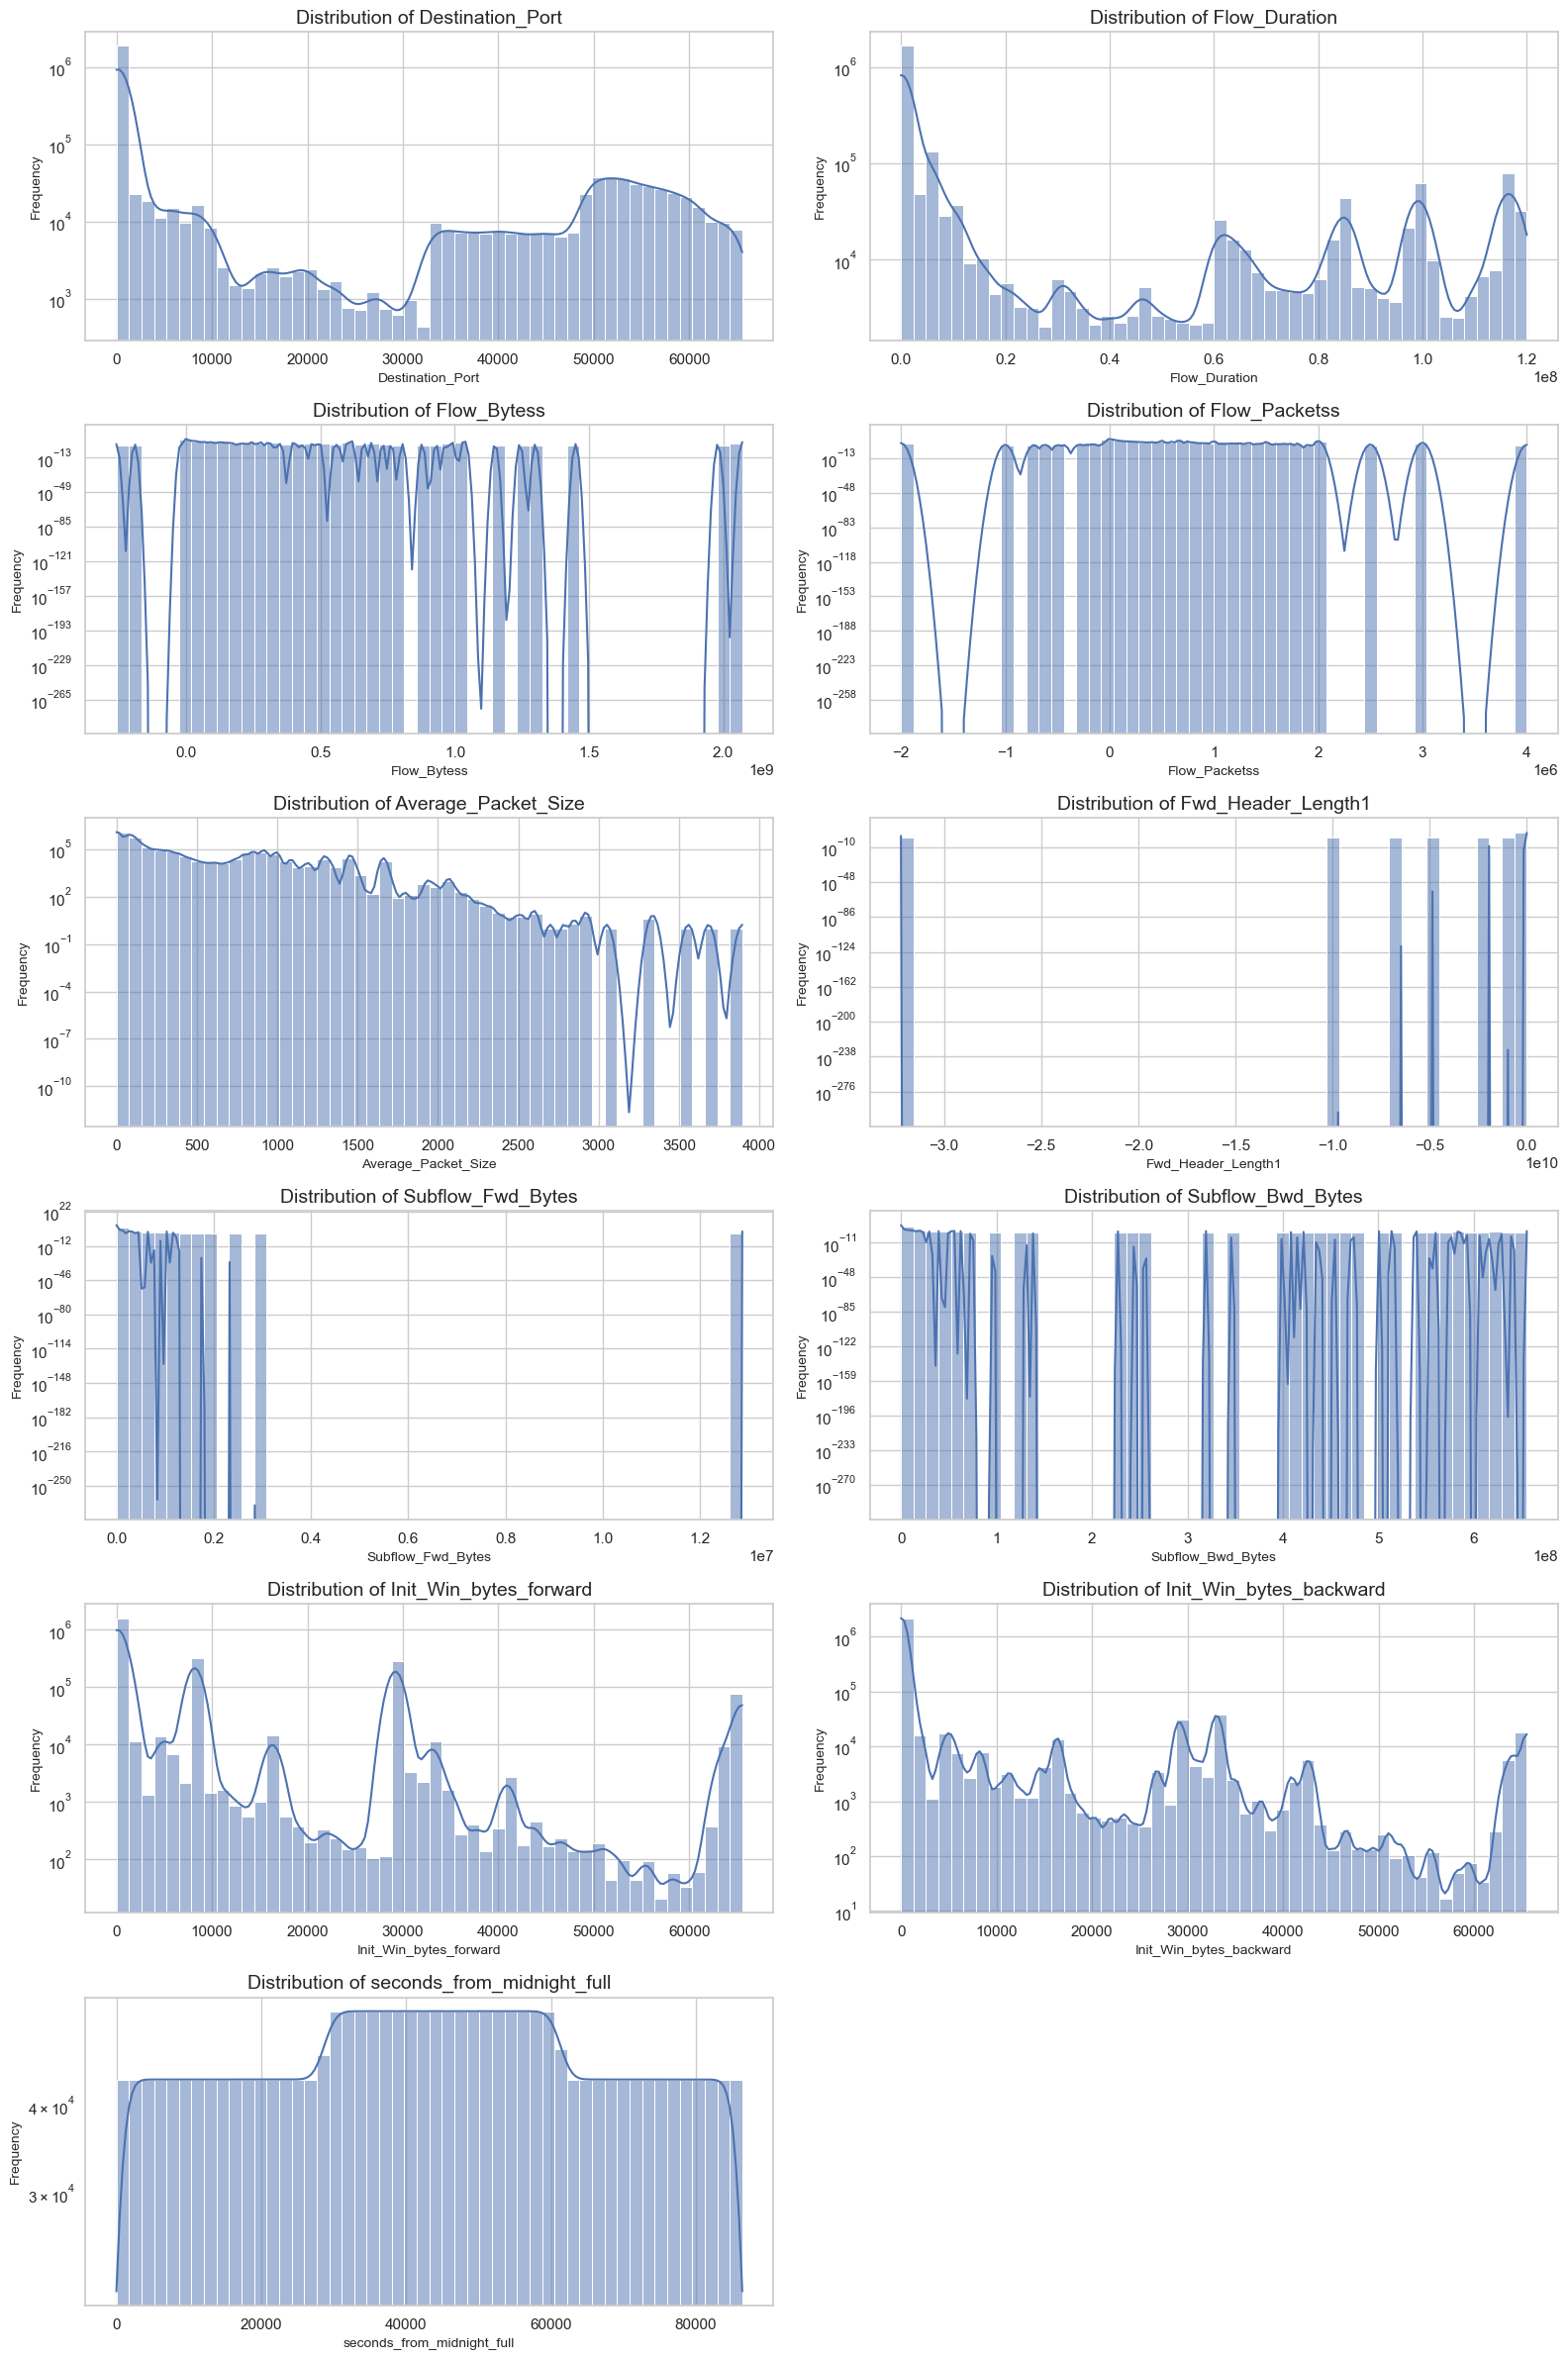

In [16]:
# Prepare X for feature distribution and correlation plots
X_eda, y_encoded_eda, le_eda = prepare_features_and_target(df_engineered.copy())
plot_feature_distributions(X_eda)

* Network Port and Flow Metrics:
    - Destination Port: Shows high concentration at low port numbers (well-known services) and a significant cluster in the 50,000–60,000 range, typical of ephemeral ports.
    - Flow Duration: Displays a multi-modal distribution with significant peaks at both very short durations and much longer intervals ($1.2 \times 10^8$ microseconds).
    - Flow Bytes and Packets: Both metrics exhibit extreme sparsity across the feature space, with narrow, high-frequency spikes appearing periodically on a log scale.

* Packet Size and Header Length: 
    - Average Packet Size: The frequency decreases as packet size increases, showing a "heavy-tail" distribution where smaller packets are vastly more common than those near 4,000 bytes.
    - Forward Header Length: This feature shows highly discrete values with extreme negative outliers ($ -3.0 \times 10^{10}$), suggesting potential data corruption or specific encoding issues in the source dataset.
    - Subflow Metrics: Both Forward and Backward Subflow Bytes show similar fragmented distributions, indicating that most subflows transfer very small amounts of data.

* TCP Windows and Temporal Progression: 

    - Initial Window Bytes (Forward/Backward): Both distributions are nearly identical and highly multi-modal. Major peaks appear at 0, 15,000, 30,000, and 65,000 bytes, which correspond to common standard TCP window size configurations.
    - Seconds from Midnight: This temporal feature shows a "plateau" distribution. The capture frequency is relatively steady throughout the day but shows a distinct, higher-volume peak during the middle of the monitoring period (roughly between 30,000 and 60,000 seconds).

Preparing features (X) and target (y)...
Original label categories: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Encoded label categories: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Shape of X: (2381639, 11), Shape of y: (2381639,)


,Destination_Port,Flow_Duration,Flow_Bytess,Flow_Packetss,Average_Packet_Size,Fwd_Header_Length1,Subflow_Fwd_Bytes,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,seconds_from_midnight_full
0,80.0,38308.0,3.132505e+02,52.208416,9.000000,20.0,6.0,6.0,255.0,946.0,28800
1,389.0,479.0,1.039666e+06,33402.922760,31.125000,368.0,172.0,326.0,29200.0,260.0,28800
2,88.0,1095.0,5.753425e+06,14611.872150,393.750000,336.0,3150.0,3150.0,29200.0,2081.0,28800
3,389.0,15206.0,6.650007e+05,1907.141918,348.689655,560.0,3452.0,6660.0,29200.0,0.0,28800
4,88.0,1092.0,5.771062e+06,13736.263740,420.133333,304.0,3150.0,3152.0,29200.0,2081.0,28800


Applying StandardScaler to features...
Features after StandardScaler (first 5 rows):


,Destination_Port,Flow_Duration,Flow_Bytess,Flow_Packetss,Average_Packet_Size,Fwd_Header_Length1,Subflow_Fwd_Bytes,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,seconds_from_midnight_full
0,-0.467753,-0.486350,-0.051634,-0.234234,-0.598805,0.001348,-0.058530,-0.007776,-0.497535,-0.153944,-0.60614
1,-0.451850,-0.487400,-0.013593,-0.074587,-0.536135,0.001363,-0.043269,-0.007647,1.446815,-0.228795,-0.60614
2,-0.467341,-0.487383,0.158934,-0.164538,0.491028,0.001361,0.230505,-0.006502,1.446815,-0.030101,-0.60614
3,-0.451850,-0.486991,-0.027306,-0.225354,0.363391,0.001371,0.258269,-0.005079,1.446815,-0.257164,-0.60614
4,-0.467341,-0.487383,0.159579,-0.168729,0.565761,0.001360,0.230505,-0.006501,1.446815,-0.030101,-0.60614


Descriptive statistics for a sample feature after scaling:


...

Descriptive statistics for a sample feature after scaling:


,Destination_Port
mean,0.139901
std,0.296481
min,0.000000
max,1.000000


Splitting data into training and testing sets...
Training RandomForestClassifier with 100 estimators...
Random Forest Classifier trained successfully.
Visualizing top 20 most important features...

Top 20 Most Important Features:


,Feature,Importance
7,Subflow_Bwd_Bytes,0.230680
4,Average_Packet_Size,0.184594
6,Subflow_Fwd_Bytes,0.136439
5,Fwd_Header_Length1,0.077917
9,Init_Win_bytes_backward,0.077093
8,Init_Win_bytes_forward,0.073638
0,Destination_Port,0.073155
1,Flow_Duration,0.046720
2,Flow_Bytess,0.039056
10,seconds_from_midnight_full,0.037846


C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_13540\126535347.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_importance_df.head(N), palette='viridis')


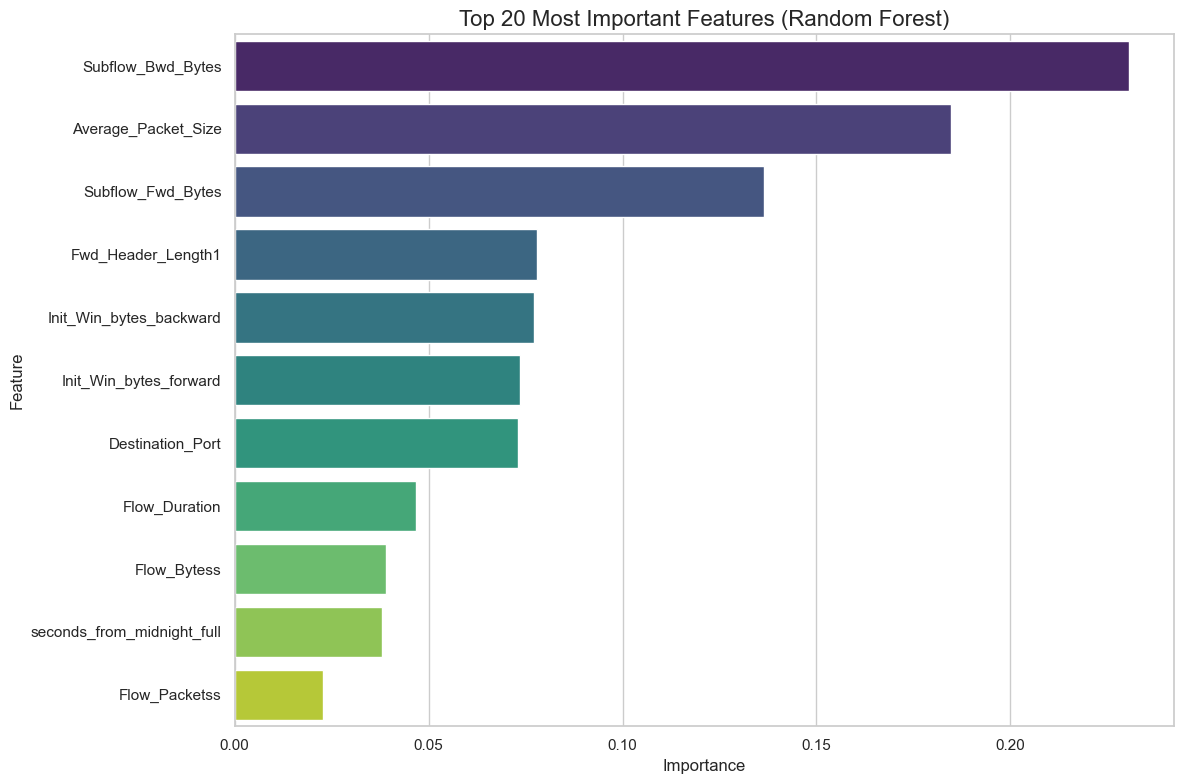

Plotting Correlation Matrix of Top 20 Important Features...


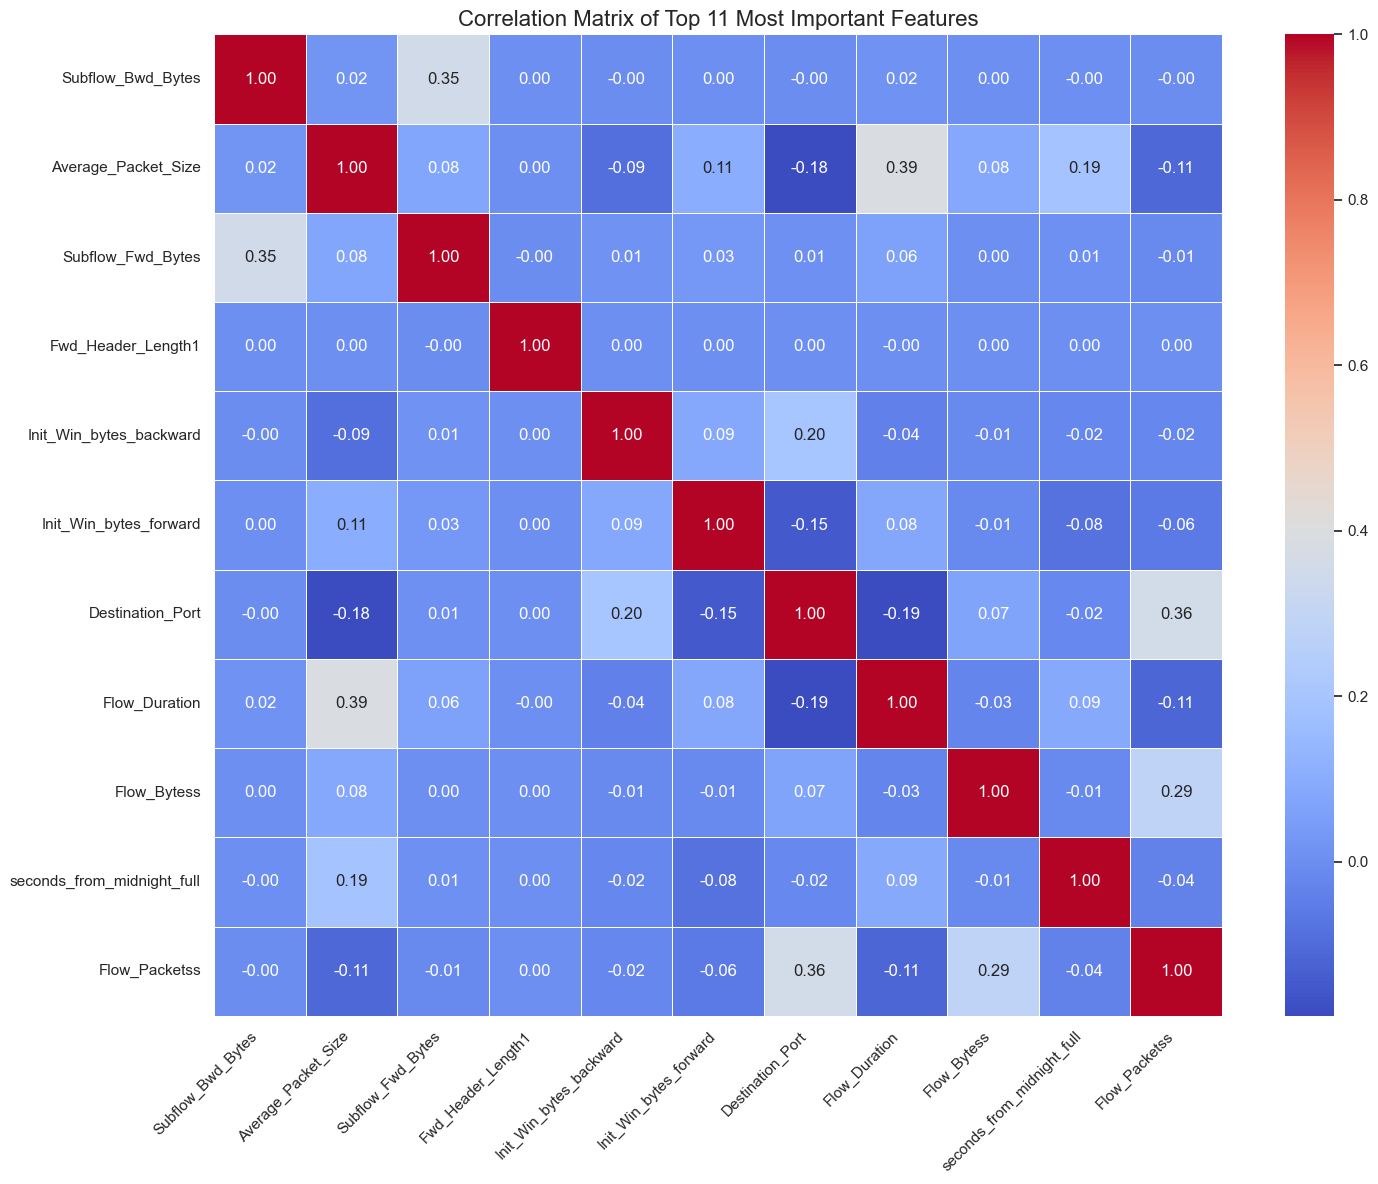

Plotting Feature Distributions by Attack Type using Violin plots...


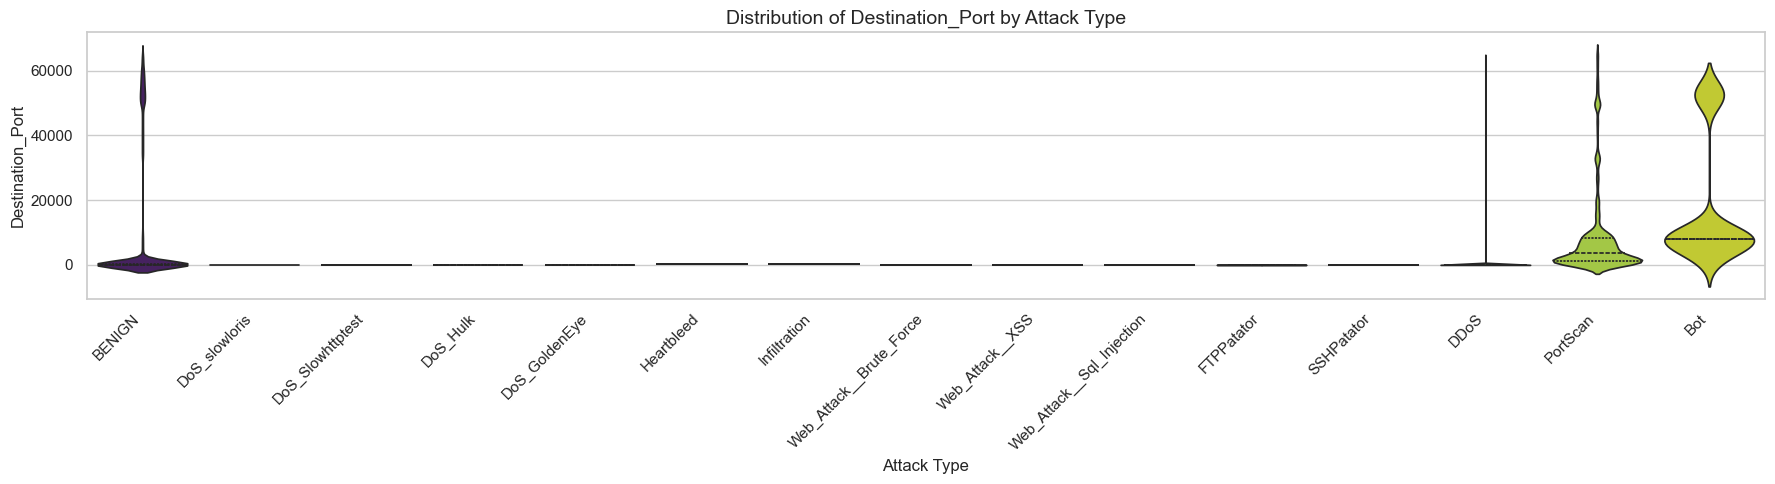

In [15]:
# Feature Selection & Scaling
X, y_encoded, label_encoder = prepare_features_and_target(df_engineered)
X_scaled_standard, scaler_standard = scale_features(X.copy(), scaler_type='StandardScaler')
X_scaled_minmax, scaler_minmax = scale_features(X.copy(), scaler_type='MinMaxScaler')

# Choosing X_scaled_standard for model training
final_X = X_scaled_standard

# Model Training & Evaluation
rf_model, X_train, X_test, y_train, y_test = train_random_forest_model(final_X, y_encoded)
feature_importances_df = visualize_feature_importances(rf_model, final_X.columns)

# Now, use the feature_importances_df for correlation plotting
plot_correlation_matrix(final_X, top_features_df=feature_importances_df)

# Plot feature distributions by attack type with the cleaned and engineered DataFrame
plot_feature_distributions_by_attack_type(df_engineered)